# Assignment 3: Linear Models

Katherine DeForrest

## Q1

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when the parameters are multipliers of the variables, rather than being multiplied together or part of another function. This means that "linear" refers to the parameters in the model, not the variables used. This is why a linear model can be a polynomial model or incorporate multiple variables.

2. You interpret the coefficient for a dummy variable as the difference in the predicted value between the category that is represented by 0 and the one that is represented as one when all other factors are constant. The intercept represents the predicted value of the baseline group, or the group when all the dummy values are 0, and the coefficient represents the difference between the two groups.

3. Linear regression should not be used for classification. The purpose of linear regression is to predict the value of a variable numerically, which does not translate well to probabilities or binary outcomes. While linear regression could hypothetically be used for classification if a certian predicted value were used as a cut-off, other models are better suited for classification than linear regression.

4. Some signs that your linear model is overfitting are that there is very low training error and very high testing error. This means that the model is fitting the training data and its noise too closely and cannot generalize to new data. In the bias-variance tradeoff, this means that there is high variance and low bias in the model.

5. Multi-colinearity is when highly correlated variables cancel each other out and explain the same variation in the outcome variable, allowing the model to have a high variance quality and "mushy predictions", and be overfitting the data. By dropping variables, it can make the model a better predictor. With the two-stage least squares technique, you can clean variables that are highly correlated or multilinear by removing the part in one explained by the other and keeping the residuals to use in model predictions. However, when  variables are multi-colinear, the difference between them may be very small and little will be left to estimate the effect of a variable.

6. You can incorporate nonlinear relatioships between your dependent variable y and your independent variable x into your analysis by adding polynomial terms or transformations of the variables, such as x^2 or log(x), into your model. This allows the model to represent nonlinear relationships in analysis even if the parameters themselves are still linear.

7. The slope coefficient in a linear regression represents the amount of change in the dependent variable given an increase of 1 in the x, or independent variable. This means that for every increase in 1 by the x variable, the predicted value would change by the value of the slope coefficient.

8. A train/test splot splits the data into two groups, one that is used to train the model and one that is sued to test the model. K-fold cross validation is similar, but splits the data into k folds rather than 2. For every value k, the model is tested on the kth fold of the data and the rest is used for training. This provies K estimates rather than one of the model's performance, allowing it to be a more accurate respresentation of the model and estimating the distribution function of the model's performance.

9. The k in k-fold validation is typically selected at the point that balances the bias-varianec trade-off. If k is larger, there is less bias and higher variance in the models, and if k is smaller, the estimates are less reliable because there are less models being tested, with more bias and less variance.

## Q2

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.00,Manhattan,Apartment,Private room
1,149,100.00,Brooklyn,Apartment,Entire home/apt
2,250,100.00,Manhattan,Apartment,Entire home/apt
3,90,94.00,Brooklyn,Apartment,Private room
4,270,90.00,Manhattan,Apartment,Entire home/apt


               Price  Review Scores Rating
Neighbourhood                             
Bronx          75.28                 91.65
Brooklyn      127.75                 92.36
Manhattan     183.66                 91.80
Queens         96.86                 91.55
Staten Island 146.17                 90.84


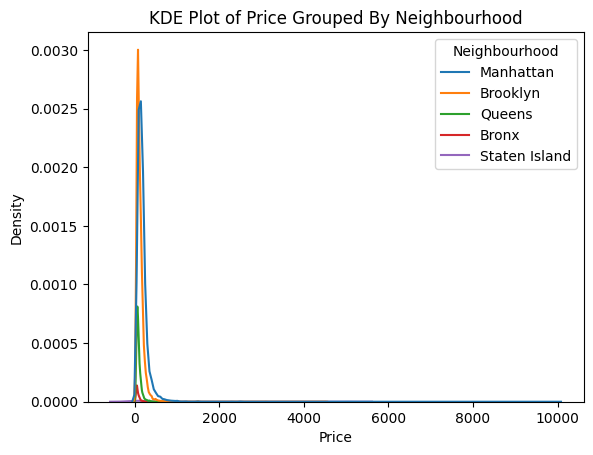

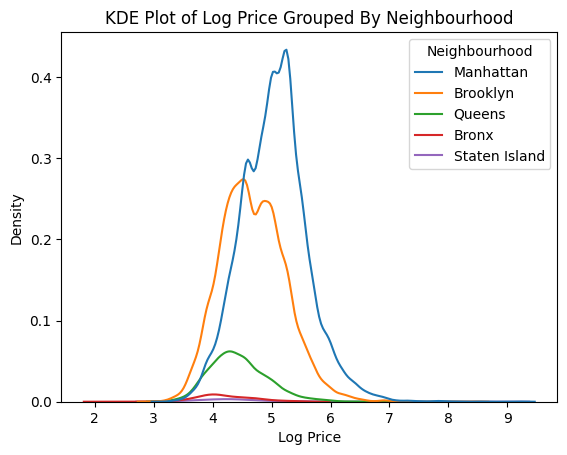

In [ ]:
#1.

df["Neighbourhood"] = df["Neighbourhood "].rename("Neighbourhood")

print(df.groupby("Neighbourhood")[["Price","Review Scores Rating"]].mean())

# Manhattan is the most expensive borough, on average.

sns.kdeplot(df, x="Price", hue="Neighbourhood")
plt.title("KDE Plot of Price Grouped By Neighbourhood")
plt.show()

df["Log Price"] = np.log(df["Price"])

sns.kdeplot(df, x="Log Price", hue="Neighbourhood")
plt.title("KDE Plot of Log Price Grouped By Neighbourhood")
plt.show()

In [ ]:
#2.

df1 = pd.get_dummies(df['Neighbourhood'], dtype='int', drop_first=True)
df1.head()

,Brooklyn,Manhattan,Queens,Staten Island
0,0,1,0,0
1,1,0,0,0
2,0,1,0,0
3,1,0,0,0
4,0,1,0,0


In [ ]:
from sklearn.linear_model import LinearRegression

y = df["Price"]
X1 = df1

model = LinearRegression()
model = model.fit(X1, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.47
1,Manhattan,108.39
2,Queens,21.58
3,Staten Island,70.89


The coefficients for the regression are directly related to those from the table in part 1. The model intercept represents the mean value of the baseline neighborhood, Bronx, that was dropped from the variable lists after the dummies were made and became the reference group. All of the estimated coefficients then represents how different each of the other neighbourhood's means are from the baseline mean. Because all of the coefficients are positive, this means they all have average prices greater than the baseline neighbourhood price.

In [ ]:
X2 = df[["Review Scores Rating"]]
y = df["Price"]

model = LinearRegression()
model = model.fit(X2, y)

print(f'Model intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_}')


Model intercept: 60.878390657123546
Slope Coefficient: [1.0208266]


The slope coefficient shows the effect that review scores has on the price. For every one-point increase in the Review Scores Rating, there is a $1.02 increase in the price of the AirBnb.

In [ ]:
#4.

X_num = df[["Review Scores Rating"]]
X3 = pd.concat([X_num, df1], axis=1)
y = df["Price"]

model = LinearRegression()
model = model.fit(X3, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: -23.812561011673324


,variable,coefficient
0,Review Scores Rating,1.08
1,Brooklyn,51.70
2,Manhattan,108.23
3,Queens,21.69
4,Staten Island,71.77


After regressing price on both the Neighbourhood and Review Scores Rating variables, the Review Scores Rating slope coefficient becomes slighly larger, while the neighbourhood averages coefficients in the model become slightly smaller.

In [ ]:
#5.


X_interactions = df1.multiply(df["Review Scores Rating"], axis=0)

X = pd.concat([X_num, X_interactions], axis=1)
y = df["Price"]

model.fit(X, y)

pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

,variable,coefficient
0,Review Scores Rating,0.22
1,Brooklyn,0.57
2,Manhattan,1.18
3,Queens,0.23
4,Staten Island,0.46


While some of the slopes are similar across neighbourhoods, such as Brooklyn and Staten Island and the baseline neighbourhood and Queens, there are large discrepencies in the coefficients. This illustrates how the slope for Review Scores Ratings varies greatly for each neighbourhood relative to the baseline neighbourhood.

In [ ]:
#6.

from sklearn.model_selection import KFold, cross_val_score

Xs = [X1, X2, X3]
model_names = ["Neighbourhood", "Review Scores Rating", "Neighbourhood and Review Scores Rating"]

for i, x in enumerate(Xs):
  model = LinearRegression()
  model.fit(x, y)

  kfold = KFold(n_splits=10, shuffle=True, random_state=100)

  neg_mse = cross_val_score(
    model, x, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

  print(f"MSE {model_names[i]}: {-np.mean(neg_mse):,.2f}")

MSE Neighbourhood: 21,159.03
MSE Review Scores Rating: 22,079.51
MSE Neighbourhood and Review Scores Rating: 21,074.10


The predictive accuracy of the model is higher when regressing Price on Neighbourhood than when on Review Scores Rating. However, the MSE decreases and is lowest when both variables are used in the model than when only one is used.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count       976.00
mean     741019.47
std      367323.38
min      188000.00
25%      475750.00
50%      666500.00
75%      883000.00
max     2941000.00
Name: Price, dtype: float64


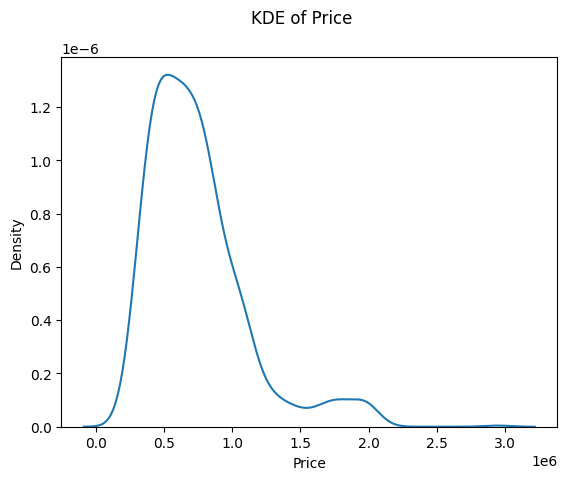

           count       mean       std       min       25%        50%  \
Body_Type                                                              
crossover  21.00  705095.24  72849.78 608000.00 638000.00  706000.00   
hatchback 484.00  533977.27 173086.73 188000.00 401750.00  509000.00   
muv        38.00  626421.05 184093.49 328000.00 489750.00  621500.00   
sedan     227.00  809784.14 286736.77 368000.00 598000.00  772000.00   
suv       206.00 1176495.15 417479.03 559000.00 860000.00 1065000.00   

                 75%        max  
Body_Type                        
crossover  749000.00  883000.00  
hatchback  661000.00 1107000.00  
muv        738500.00 1091000.00  
sedan      968500.00 2941000.00  
suv       1491250.00 2100000.00  


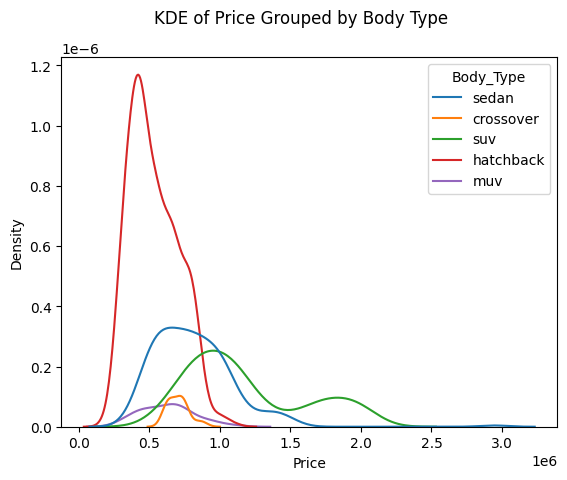

In [ ]:
#1
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv("/content/cars_hw.csv")
df.head()

print(df["Price"].describe())
sns.kdeplot(df, x="Price")
plt.suptitle("KDE of Price")
plt.show()

print(df.groupby("Body_Type")["Price"].describe())
sns.kdeplot(df, x="Price", hue="Body_Type")
plt.suptitle("KDE of Price Grouped by Body Type")
plt.show()

The car types that are the most expensive are the SUV and the Sedan, according to their median and mean values. SUVs and Sedans also have the highest standard deviation, or variation in their prices.

In [ ]:
#2.

from sklearn.linear_model import LinearRegression

X = df[["Seating_Capacity"]]
y = df["Price"]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_}')

Model intercept: 439032.0141018266
Slope Coefficient: [59267.99803672]


Interpretation of Slope Coefficient: For every increase of 1 of the Seating Capacity of a car, there is a predicted 59,267.998 rupee increase in the predicted price of the car.

In [ ]:
seating_dummies = pd.get_dummies(df["Seating_Capacity"], dtype="int", drop_first=True)
X = seating_dummies
y = df["Price"]

model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
coefficients = pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })
print(coefficients)

Model intercept: 188000.00000000314
   variable  coefficient
0         5    546483.87
1         6   1456000.00
2         7    735948.72
3         8    271800.00


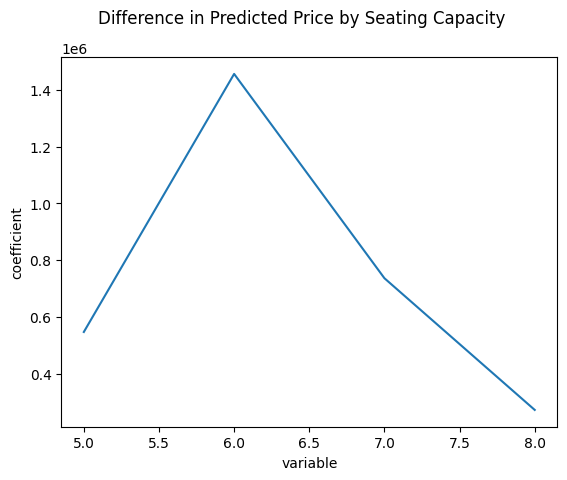

In [ ]:
sns.lineplot(coefficients, x ="variable", y="coefficient")
plt.suptitle("Difference in Predicted Price by Seating Capacity")
plt.show()

The differences in price are not roughly linear with the number of seats, as seen in the graph above. With a baseline price of 188000 for four seats, there is an increase in the difference between the predicted increase in price with another seat for 5 seats, and an even greater increast for 6 seats. However, this increase starts to be smaller for 7 seats and 8 seats. This indicates a non-linear relationship between seating capacity and differences in price.

Degree 1: 97,593,991,873.85
Degree 2: 97,788,769,710.30
Degree 3: 97,182,824,586.85
Degree 4: 96,657,152,963.87
Degree 5: 95,734,209,145.18
Degree 6: 95,928,603,339.20
Degree 7: 95,394,591,823.73
Degree 8: 95,673,788,591.44
Degree 9: 95,632,519,298.56
Degree 10: 95,354,958,984.83
Degree 11: 95,146,668,073.44
Degree 12: 95,292,199,598.31
Degree 13: 95,798,289,965.10
Degree 14: 96,410,294,715.11
Optimal polynomial degree: 11


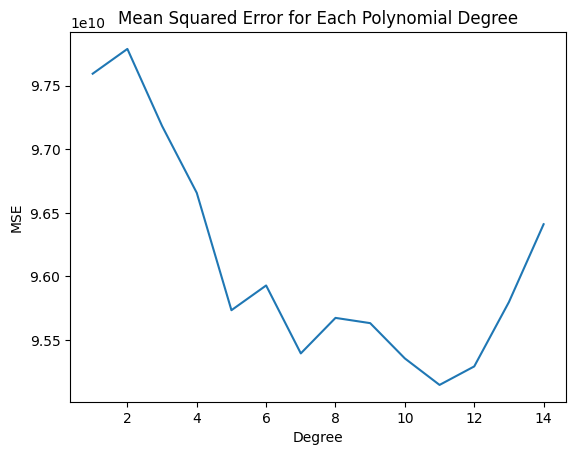

In [ ]:
#3.

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures

df["Age"] = 2026 - df["Make_Year"]
df.head()

X = df[["Age"]]
y = df["Price"]

degrees = range(1, 15)
scores = []

model = LinearRegression()
model = model.fit(X, y)

for degree in degrees:
    expander = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = expander.fit_transform(X)

    kfold = KFold(n_splits=10, shuffle=True, random_state=100)

    neg_mse = cross_val_score(
        model, X_poly, y,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )

    scores.append(-np.mean(neg_mse))

    print(f"Degree {degree}: {-np.mean(neg_mse):,.2f}")

optimal_degree_index = np.argmin(scores) #index of minimum mse score
optimal_degree = degrees[optimal_degree_index]

print(f"Optimal polynomial degree: {optimal_degree}")

sns.lineplot(x=degrees, y=scores)
plt.title('Mean Squared Error for Each Polynomial Degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.show()

From the above graph and lists of MSE, the 11th degree polynomial results in the lowest overall mean squared error. Therefore, the optimal number of powers of Age to include in a regression of price and age is 11.

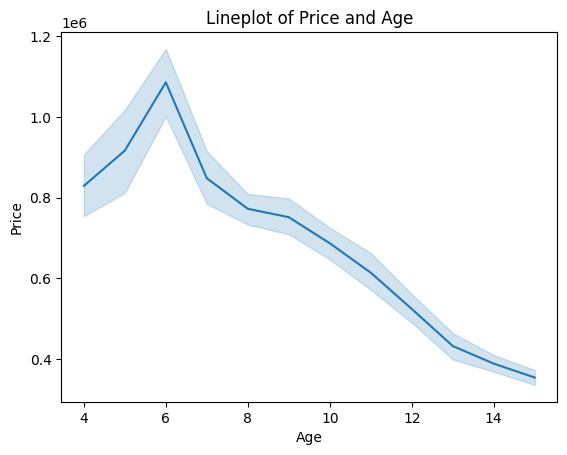

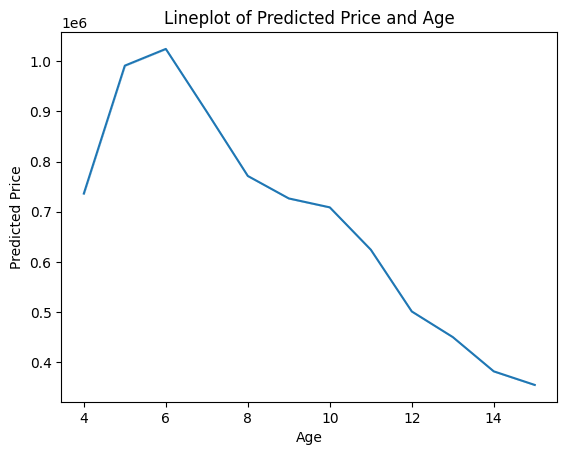

In [ ]:
#4.

sns.lineplot(data=df, x="Age", y="Price")
plt.title("Lineplot of Price and Age")
plt.show()

X = df[["Age"]]
y = df["Price"]

expander = PolynomialFeatures(degree=11, include_bias=False)
X_poly = expander.fit_transform(X)

model = LinearRegression()
model = model.fit(X_poly, y)

df["Predicted Price"] = model.predict(X_poly)

sns.lineplot(data=df, x="Age", y="Predicted Price")
plt.title("Lineplot of Predicted Price and Age")
plt.show()

Yes, the model of the 11th degree polynomial accurately fits the patterns in the data. The line plot of price and age is very similar and fits patterns in the data closely to age and the predicted price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [ ]:
#1.
df = pd.read_csv("/content/heart_hw.csv")
df.head()

#a.
df_control = df[df["transplant"] == "control"]
#b.
df_treatment = df[df["transplant"] == "treatment"]

control_rate = df_control["y"].mean()
print("Proportion of people who survive the control group:", control_rate)
treatment_rate = df_treatment["y"].mean()
print("Proportion of people who survive the treatment group:", treatment_rate)

ATE = treatment_rate - control_rate
print("ATE:", ATE)

Proportion of people who survive the control group: 0.11764705882352941
Proportion of people who survive the treatment group: 0.34782608695652173
ATE: 0.23017902813299232


The ATE on three-year survival for heart transplants is .230.

In [ ]:
#2.
df["transplant_numerical"] = df["transplant"].map({"control": 0, "treatment": 1})

X1 = df[["transplant_numerical"]]
y = df["y"]

model = LinearRegression()
model.fit(X1,y)

print(f'Model intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_}')

Model intercept: 0.1176470588235293
Slope Coefficient: [0.23017903]


The intercept of the model is the proportion of people who survive the control group, while the slope coefficient is the ATE, which is the difference in the survival proportion between the treatment and control groups.

In [ ]:
#3.

X2 = df[['transplant_numerical', 'age']]
y = df['y']

model = LinearRegression()
model.fit(X2,y)

print(f'Model intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_}')

Model intercept: 0.7019569721740947
Slope Coefficient: [ 0.26470169 -0.01360722]


The coefficent on transplant increases slightly when you control for age. This means that, when age is constant, recieving a transplant increases the predicted probability of survival by .265.

The intercept represents the probability of survival for a person who is in the control group, or didn't have a transplant, and is 0 years old. Because a 0 year old is unlikely to get a heart transplant, the intercept is not very relevant in this model.

The slopes represent the increase or decrease in the predicted probability of survival when holding the other variable constant. So, for the transplant coefficient of .265, this means that, when holding age constant, the predicted three-year survival rate increases by .265. Similarly, for the slope coefficient for age of -.014, when holding the transplant status constant, for every one-year increase in age, the predicted probability of survival decreases by .014.

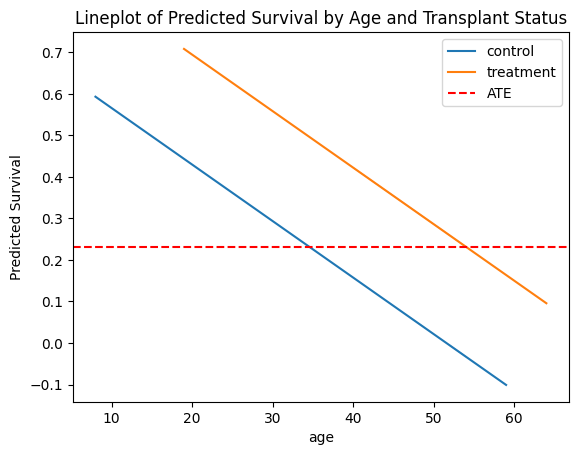

In [ ]:
df["Predicted Survival"] = model.predict(X)

sns.lineplot(data=df, x="age", y="Predicted Survival", hue="transplant")
plt.title("Lineplot of Predicted Survival by Age and Transplant Status")
plt.axhline(ATE, linestyle="--", label="ATE", color="red")
plt.legend()
plt.show()

The current model contains no age-transplant interaction, and the ATE is the treatment effect at all ages, so the difference between the two lines is the same the whole time. Because of this, there is no underestimation or overestimation at any age, but in reality, if effect does vary with age, then the ATE could be underestimating at some ages and overestimating at others.

In [ ]:
#4.
df["transplant_age"] = df["transplant_numerical"] * df["age"]

X3 = df[['transplant_numerical', 'age', 'transplant_age']]
y = df['y']

model = LinearRegression()
model.fit(X3,y)

print(f'Model intercept: {model.intercept_}')
print(f'Slope Coefficient: {model.coef_}')

Model intercept: 0.35486517529945855
Slope Coefficient: [ 0.90775139 -0.00552426 -0.01459064]


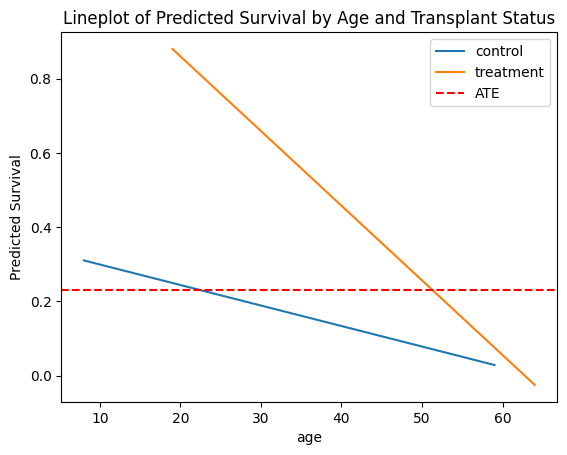

In [ ]:
df["Predicted Survival"] = model.predict(X)

sns.lineplot(data=df, x="age", y="Predicted Survival", hue="transplant")
plt.title("Lineplot of Predicted Survival by Age and Transplant Status")
plt.axhline(ATE, linestyle="--", label="ATE", color="red")
plt.legend()
plt.show()

Allowing age and transplant to interact changes my predictions.

The intercept has decreased from .7 to .35. The transplant coefficient increased from .26 to .91, which represents the predicted transplant effect at age 0. The age coefficient increased from -.0136 to -.0055, which represents the change in predicted probability of survival when holding transplant status constant.

The transplant_age coefficient, which represents the interaction, is -.0146. This means that the impact of a transplant decreases as age increases.

From the graph, the changes in the slopes for both the control and treatment groups indicates that transplant effect changes with age. As age increases, the predicted survival for both groups decreases, but it is steeper negative slope for the treatment group. This means that the impact of a transplant decreases when a person is older.

This therefore means the previous models underestimated the impact of a transplant for younger individuals, but overestimated the impact of a transplant for older people, given the decreasing impact of a transplant with age.

In [ ]:
#5.
from sklearn.model_selection import KFold, cross_val_score

Xs = [X1, X2, X3]
model_names = ["Model 1 (Transplant Only)", "Model 2 (Transplant and Age)", "Model 3 (Transplant, Age, and Interaction)"]

for i, x in enumerate(Xs):
  model = LinearRegression()
  model.fit(x, y)

  kfold = KFold(n_splits=10, shuffle=True, random_state=100)

  neg_mse = cross_val_score(
    model, x, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

  print(f"MSE {model_names[i]}: {-np.mean(neg_mse):,.2f}")

MSE Model 1 (Transplant Only): 0.19
MSE Model 2 (Transplant and Age): 0.18
MSE Model 3 (Transplant, Age, and Interaction): 0.18


The predictive accuracy increases when age is included in the model, but does not when the interaction term is added.

6. If this model was used to grant transplant access, I would be concerned that the model would not be able to fully capture the nuance needed to determine who needs a transplant most. While age may be a good indicator of whether a transplant is effective, there are many other variables that could impact this model that are currently not included such as medical, social, and psychological factors. Furthermore, many more variables would need to be included to make it more accurate. It would also be effective to include the impacts of the transplant beyond simply a 3 year surival rate, as there are many other effects and the desired impact of a transplant should not just be that the person lives for three years. Finally, there are ethical concerns about using a model to determine who should recieve a transplant, given that the model may have bias in it and may not be transparent. When using it for situations that have very real-world impacts, it would not be ethical to use a model that had bias or was not entirely accurate, and did not factor in other real concerns or nuances about different situatins when considering who to prioritize transplance access for.